<a href="https://colab.research.google.com/github/TanviDhuri18/CSL701-CS13_Machine-Learning-Lab/blob/main/ML_EXP2_CS13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Tanvi Dasharath Dhuri Roll no : CS13 Batch :cs01

Experiment 2
Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


Objectives
Understand SLR
Load/preprocess dataset
Perform EDA
Compute OLS coefficients
Evaluate with SSE, MSE, R²
Visualize regression and residual plots


Software Requirements

Python 3.x
Jupyter/Colab/VS Code
Libraries: pandas, numpy, matplotlib, seaborn


Theory


Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:
yˆ=w0+w1x1

In matrix form, including the bias/intercept term X0=1:
yˆ=Xw

To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:
SSE=i=1Nyi-yˆi2=y-XwTy-Xw

Solving for w analytically yields the normal equation:
wˆ=XTX-1XTy

Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


Algorithm
Import libraries
Load Auto MPG dataset
Inspect and clean data
Select horsepower and mpg
Plot scatter graph
Add bias term
Compute correlation
Calculate OLS weights
Predict values
Compute residuals
Calculate SSE, MSE, R²
Plot regression and residual graphs
Interpret results.
Upload the google colab onto Git hub repository






FIRST FIVE ROWS
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Dataset Shape: (398, 9)


DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-nu

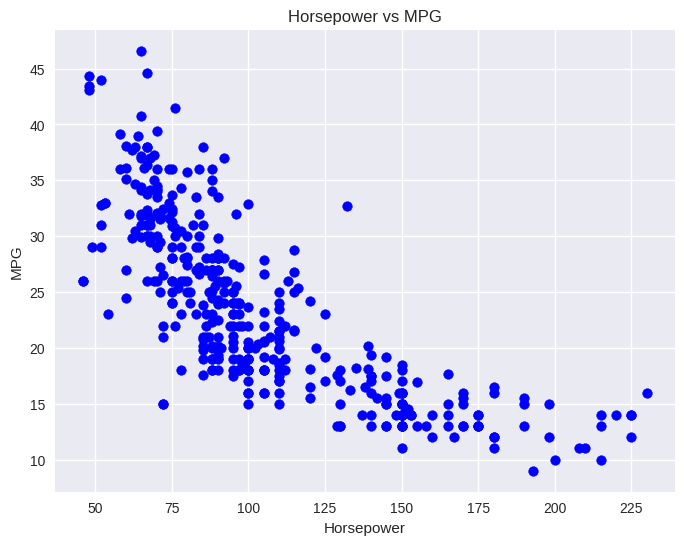


Bias Matrix (First Five Rows)
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]

Correlation Coefficient = -0.7784267838977756

Intercept = 39.9358610211705
Slope = -0.15784473335365387

First 10 Predictions
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]

First 10 Residuals
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]

MODEL EVALUATION
SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


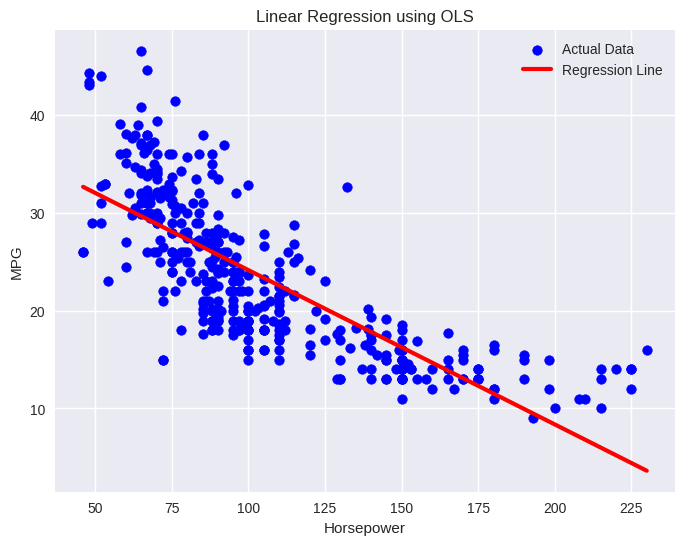

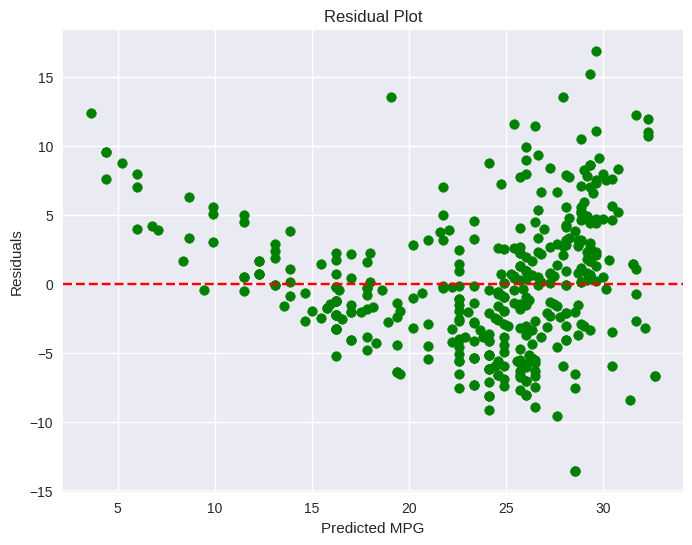



INTERPRETATION
Correlation Coefficient : -0.7784
Intercept               : 39.9359
Slope                   : -0.1578
SSE                     : 9385.9159
MSE                     : 23.9437
R² Score                : 0.6059

Conclusion:
• Horsepower and MPG have a negative relationship.
• As horsepower increases, fuel efficiency (MPG) decreases.
• The regression line predicts MPG from horsepower.
• Residuals represent prediction errors.
• Residuals close to zero indicate good predictions.
• The model provides a moderate fit to the data.

Program Executed Successfully!


In [12]:
# ==========================================================
# LINEAR REGRESSION USING ORDINARY LEAST SQUARES (OLS)
# AUTO MPG DATASET
# ==========================================================

# ----------------------------
# Step 1: Import Libraries
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# ----------------------------
# Step 2: Load Auto MPG Dataset
# ----------------------------
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

print("="*60)
print("FIRST FIVE ROWS")
print(df.head())

print("\nDataset Shape:", df.shape)

# ----------------------------
# Step 3: Inspect and Clean Data
# ----------------------------
print("\n")
print("="*60)
print("DATA INFORMATION")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Select only horsepower and mpg
df = df[['horsepower','mpg']]

# Remove missing values
df = df.dropna()

print("\nCleaned Dataset")
print(df.head())

print("\nCleaned Shape:", df.shape)

# ----------------------------
# Step 4: Select Horsepower and MPG
# ----------------------------
X = df['horsepower'].values
Y = df['mpg'].values

# ----------------------------
# Step 5: Scatter Plot
# ----------------------------
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)
plt.show()

# ----------------------------
# Step 6: Add Bias Term
# ----------------------------
X_bias = np.c_[np.ones(len(X)), X]

print("\nBias Matrix (First Five Rows)")
print(X_bias[:5])

# ----------------------------
# Step 7: Compute Correlation
# ----------------------------
correlation = np.corrcoef(X,Y)[0,1]

print("\nCorrelation Coefficient =", correlation)

# ----------------------------
# Step 8: Calculate OLS Weights
# W = (X'X)^(-1)X'Y
# ----------------------------
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

intercept = weights[0]
slope = weights[1]

print("\nIntercept =", intercept)
print("Slope =", slope)

# ----------------------------
# Step 9: Predict Values
# ----------------------------
Y_pred = X_bias @ weights

print("\nFirst 10 Predictions")
print(Y_pred[:10])

# ----------------------------
# Step 10: Compute Residuals
# ----------------------------
residuals = Y - Y_pred

print("\nFirst 10 Residuals")
print(residuals[:10])

# ----------------------------
# Step 11: Calculate SSE, MSE and R²
# ----------------------------
SSE = np.sum(residuals**2)

MSE = np.mean(residuals**2)

SST = np.sum((Y - np.mean(Y))**2)

R2 = 1 - (SSE/SST)

print("\n==============================")
print("MODEL EVALUATION")
print("==============================")
print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)

# ----------------------------
# Step 12: Plot Regression Line
# ----------------------------
sort_index = np.argsort(X)

plt.figure(figsize=(8,6))

plt.scatter(X, Y,
            color='blue',
            label='Actual Data')

plt.plot(X[sort_index],
         Y_pred[sort_index],
         color='red',
         linewidth=3,
         label='Regression Line')

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear Regression using OLS")
plt.legend()
plt.grid(True)

plt.show()

# ----------------------------
# Step 13: Residual Plot
# ----------------------------
plt.figure(figsize=(8,6))

plt.scatter(Y_pred,
            residuals,
            color='green')

plt.axhline(y=0,
            color='red',
            linestyle='--')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)

plt.show()

# ----------------------------
# Step 14: Interpretation
# ----------------------------
print("\n")
print("="*60)
print("INTERPRETATION")
print("="*60)

print(f"Correlation Coefficient : {correlation:.4f}")
print(f"Intercept               : {intercept:.4f}")
print(f"Slope                   : {slope:.4f}")
print(f"SSE                     : {SSE:.4f}")
print(f"MSE                     : {MSE:.4f}")
print(f"R² Score                : {R2:.4f}")

print("\nConclusion:")

if correlation < 0:
    print("• Horsepower and MPG have a negative relationship.")
else:
    print("• Horsepower and MPG have a positive relationship.")

print("• As horsepower increases, fuel efficiency (MPG) decreases.")
print("• The regression line predicts MPG from horsepower.")
print("• Residuals represent prediction errors.")
print("• Residuals close to zero indicate good predictions.")

if R2 >= 0.80:
    print("• The model provides a strong fit to the data.")
elif R2 >= 0.60:
    print("• The model provides a moderate fit to the data.")
else:
    print("• The model provides a weak fit to the data.")

print("\nProgram Executed Successfully!")